# 03 Visium cell2location

Starter notebook for Visium deconvolution with cell2location.

**Goal:**
- estimate how much of each cell type is present in each Visium spot
- result: spot-by-cell-type abundance matrix and spatial maps you can compare with Xenium.

Single Cell RNAseq methods resolve gene expression at the single cell level, but lose the spatial context of the cells. Visium spatial gene expression maintains spatial information, but the resolution of each spot can cover is limited with each spot covering multiple cells (typically 1-10 cells).

With their complementary strengths these data types are a prime target for integration. The current computational tools for single cell and Visium integration fall on a continuum between deconvolution and mapping approaches. Deconvolution methods aim to identify the cell types and their relative proportions contributing to a spot, while mapping methods seek to assign the most likely dominant cell type to a spot.

**Cell2location** is a Bayesian model that is designed to resolve fine-grained cell types in spatial transcriptomic data as well as create cellular maps of diverse tissues. It can handle complex experimental settings, enabling the joint analysis of multiple scRNA-seq and spatial transcriptomic datasets. 

Great notes: 
- https://www.10xgenomics.com/analysis-guides/integrating-single-cell-and-visium-spatial-gene-expression-data
- https://cell2location.readthedocs.io/en/latest/notebooks/cell2location_tutorial.html#Loading-Visium-and-scRNA-seq-reference-data


In [ ]:
import scanpy as sc
import cell2location
import scvi
import pandas as pd


from pathlib import Path
import matplotlib.pyplot as plt


In [28]:
PROJECT_ROOT = Path("..")
OUT_DIR = PROJECT_ROOT / "data" / "visium"
OUT_DIR.mkdir(parents=True, exist_ok=True)


# Input 1: reference from Notebook 1 
# (with cell_type labels and reference signatures).
reference_H5 = PROJECT_ROOT / "data" / "reference" / "reference_qc_annotated_for_transfer.h5ad"
adata_ref = sc.read_h5ad(reference_H5)


# Input 2: QC'd Visium object from Notebook 2 
visium_H5 = PROJECT_ROOT / "data" / "visium" /  "visium_qc_for_cell2location.h5ad"
adata_visium = sc.read_h5ad(visium_H5)


##  Build reference signatures from scRNA reference

In [29]:

# Confirm cell_type exists
print("cell_type in obs:", "cell_type" in adata_ref.obs.columns)
print(adata_ref.obs["cell_type"].value_counts(dropna=False).head())

adata_ref.obs["cell_type"] = adata_ref.obs["cell_type"].astype(str).fillna("Unknown")
adata_ref = adata_ref[adata_ref.obs["cell_type"] != "Unknown"].copy()

# Use raw counts layer for cell2location regression
# (Notebook 1 saved raw counts in layers["counts"])
cell2location.models.RegressionModel.setup_anndata(
    adata=adata_ref,
    labels_key="cell_type",
    layer="counts"
)

cell_type in obs: True
cell_type
Epithelial cells          10652
T cells                    2730
Breast glandular cells     1082
Breast cancer               819
B cells                     360
Name: count, dtype: int64


In [30]:
print(adata_ref.obs["cell_type"])

AAACCTGAGAACAACT-1             T cells
AAACCTGAGACTTGAA-1    Epithelial cells
AAACCTGAGCAGGCTA-1    Epithelial cells
AAACCTGAGCTAGTGG-1    Epithelial cells
AAACCTGAGGATGCGT-1    Epithelial cells
                            ...       
TTTGTCACAATGTTGC-4    Epithelial cells
TTTGTCACATCGATGT-4    Epithelial cells
TTTGTCAGTAAGAGGA-4             T cells
TTTGTCAGTCAAAGCG-4    Epithelial cells
TTTGTCATCAACGAAA-4    Epithelial cells
Name: cell_type, Length: 16692, dtype: object


In [18]:
# 1. Train reference signature model (scRNA reference)
# - initializes a probabilistic regression model using the reference AnnData
# - optimizes model parameters for 250 epochs to learn:
# - per-cell-type gene expression signatures (used later as inf_aver)
# - nuisance terms (e.g., sequencing depth/technical effects) so signatures are more robust

# HEre is where cell2location “learns what each cell type looks like”
# from adata_ref; the next step (export_posterior) extracts those 
# learned signatures for Visium mapping.

reg_model = cell2location.models.RegressionModel(adata_ref)
reg_model.train(max_epochs=250)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/katwre/projects/visium-xenium-scFFPEseqreference-mapping/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
/home/katwre/projects/visium-xenium-scFFPEseqreference-mapping/.venv/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/katwre/projects/visium-xenium-scFFPEseqreference-mapping/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many

Epoch 250/250: 100%|██████████| 250/250 [10:04<00:00,  1.76s/it, v_num=1, elbo_train=1.27e+7]

`Trainer.fit` stopped: `max_epochs=250` reached.


Epoch 250/250: 100%|██████████| 250/250 [10:04<00:00,  2.42s/it, v_num=1, elbo_train=1.27e+7]


In [31]:
reg_model

RegressionBackgroundDetectionTech model with the following params: 
n_factors: 10 
n_batch: 1 
Training status: Trained

In [32]:
# Export posterior from trained reference model
#Bayesian idea:
#Prior = assumptions before data
#Likelihood = how data supports parameter values
#Posterior = updated distribution after combining both
#For this RegressionModel, 
#posterior contains uncertainty-aware estimates of:
#- cell-type-specific expression signatures per gene,
#- technical/noise parameters.
adata_ref = reg_model.export_posterior(
    adata_ref,
    sample_kwargs={"num_samples": 1000, "batch_size": 2500}
)

print("varm keys:", list(adata_ref.varm.keys()))
print("example var cols:", list(adata_ref.var.columns)[:20])

Sampling global variables, sample: 100%|██████████| 999/999 [00:47<00:00, 20.92it/s]
varm keys: ['PCs', 'means_per_cluster_mu_fg', 'stds_per_cluster_mu_fg', 'q05_per_cluster_mu_fg', 'q95_per_cluster_mu_fg']
example var cols: ['gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std']


In [35]:
# Build signature matrix for downstream Visium mapping
if "means_per_cluster_mu_fg" in adata_ref.varm:
    inf_aver = adata_ref.varm["means_per_cluster_mu_fg"]
elif "means_per_cluster_mu_fg" in adata_ref.var:
    inf_aver = adata_ref.var["means_per_cluster_mu_fg"]
else:
    raise KeyError("Could not find exported signatures: means_per_cluster_mu_fg")

print(type(inf_aver))
print("Shape:", inf_aver.shape)

<class 'pandas.core.frame.DataFrame'>
Shape: (3000, 10)


In [36]:
# Save signatures to reuse
ref_signatures_fp = OUT_DIR / "reference_signatures_inf_aver.csv"
if hasattr(inf_aver, "to_csv"):
    inf_aver.to_csv(ref_signatures_fp)
    print(f"Saved signatures: {ref_signatures_fp}")

Saved signatures: ../data/visium/reference_signatures_inf_aver.csv


## Prepare Visium for mapping

In [ ]:
# Just make sure that I didnt filter here fo rthe most highly 
# variable genes, but we take into account all the genes
print(adata_visium.shape)
# It's HVG-trimmed, which means I reduced the dataset 
# to only Highly Variable Genes (HVGs) and dropped the rest
# print(adata_visium.shape) -> (3245, 3000)
# Visium went from many genes to ~3000 genes ((3245, 3000)), 
# which is great for clustering/UMAP speed, 
# but not ideal for cell2location deconvolution (it usually benefits from a broader gene set for signature matching).



(3245, 18085)


In [38]:
# Intersect genes between adata_visium and the signature matrix.
# Prepare Visium for mapping with currently available genes

common_genes = adata_visium.var_names.intersection(inf_aver.index)
print("Common genes:", len(common_genes))

adata_visium_map = adata_visium[:, common_genes].copy()
inf_aver_map = inf_aver.loc[common_genes, :].copy()

cell2location.models.Cell2location.setup_anndata(
    adata=adata_visium_map,
    layer="counts"
)

print(adata_visium_map.shape, inf_aver_map.shape)

Common genes: 2009
(3245, 2009) (2009, 10)


In [40]:
# Set up anndata for spatial model with cell2location.models.Cell2location.setup_anndata(...).
cell2location.models.Cell2location.setup_anndata(
    adata=adata_visium_map,
    layer="counts"
)
print("Shape:", adata_visium_map.shape)

Shape: (3245, 2009)


## Run spatial mapping model


In [41]:
# Train cell2location.models.Cell2location(...) on Visium
cell2loc_model = cell2location.models.Cell2location(
    adata_visium_map,
    cell_state_df=inf_aver_map,
    N_cells_per_location=10,
    detection_alpha=20
)

cell2loc_model.train(
    max_epochs=5000,
    train_size=1,
    batch_size=None
)

# Export posterior; this creates spot-level cell abundance columns in adata_visium.obs.
adata_visium_map = cell2loc_model.export_posterior(
adata_visium_map,
sample_kwargs={"num_samples": 1000, 
               "batch_size": adata_visium_map.n_obs
               }
)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/katwre/projects/visium-xenium-scFFPEseqreference-mapping/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
/home/katwre/projects/visium-xenium-scFFPEseqreference-mapping/.venv/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/katwre/projects/visium-xenium-scFFPEseqreference-mapping/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many

Epoch 5000/5000: 100%|██████████| 5000/5000 [39:39<00:00,  2.15it/s, v_num=1, elbo_train=4.94e+6]  

`Trainer.fit` stopped: `max_epochs=5000` reached.


Sampling global variables, sample: 100%|██████████| 999/999 [00:48<00:00, 20.73it/s]


In [42]:
# Save trained Cell2location model
model_dir = OUT_DIR / "cell2location_model"
cell2loc_model.save(model_dir, overwrite=True)

#save trained reference regression model too
ref_model_dir = OUT_DIR / "cell2location_reference_regression_model"
reg_model.save(ref_model_dir, overwrite=True)


In [43]:
print("obsm keys:", list(adata_visium_map.obsm.keys()))

obsm keys: ['spatial', 'means_cell_abundance_w_sf', 'stds_cell_abundance_w_sf', 'q05_cell_abundance_w_sf', 'q95_cell_abundance_w_sf']


Added columns: ['c2l_q05cell_abundance_w_sf_means_per_cluster_mu_fg_Adipocytes', 'c2l_q05cell_abundance_w_sf_means_per_cluster_mu_fg_B cells', 'c2l_q05cell_abundance_w_sf_means_per_cluster_mu_fg_Breast cancer', 'c2l_q05cell_abundance_w_sf_means_per_cluster_mu_fg_Breast glandular cells', 'c2l_q05cell_abundance_w_sf_means_per_cluster_mu_fg_Endothelial cells']


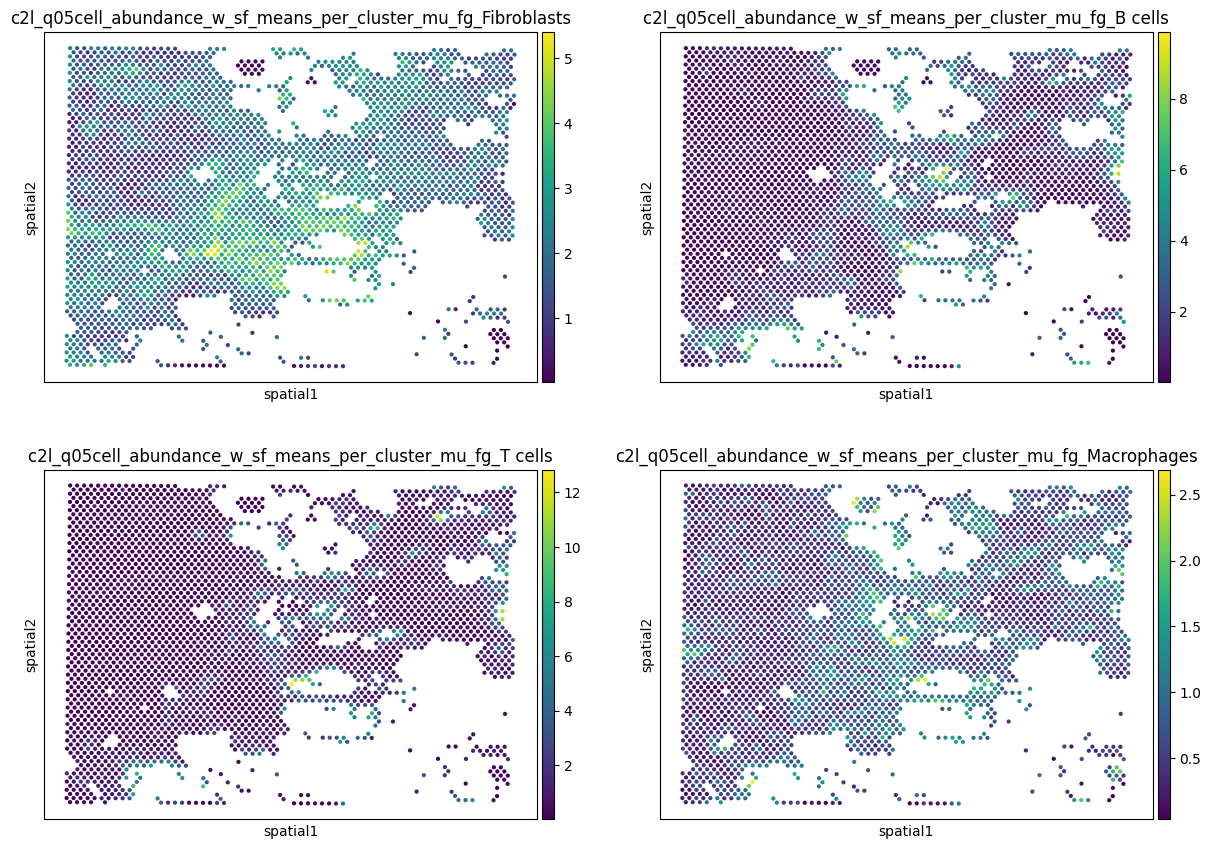

In [44]:
## Visualize and save
# Plot abundance maps with sc.pl.embedding(adata_visium, #basis="spatial", color=[...]).
# Save final mapped object to visium.

abundance = adata_visium_map.obsm["q05_cell_abundance_w_sf"].copy()
for ct in abundance.columns:
    adata_visium_map.obs["c2l_" + ct] = abundance[ct].values
print("Added columns:", [c for c in adata_visium_map.obs.columns if c.startswith("c2l_")][:5])


top_ct = abundance.mean(axis=0).sort_values(ascending=False).head(4).index.tolist()
sc.pl.embedding(
    adata_visium_map,
    basis="spatial",
    color=["c2l_" + c for c in top_ct],
    ncols=2
)


In [45]:
# Save final mapped object
mapped_out_fp = OUT_DIR / "visium_cell2location_mapped.h5ad"
adata_visium_map.write_h5ad(mapped_out_fp)
print(f"Saved: {mapped_out_fp}")
print(adata_visium_map)

Saved: ../data/visium/visium_cell2location_mapped.h5ad
AnnData object with n_obs × n_vars = 3245 × 2009
    obs: 'in_tissue', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'pct_counts_mt', '_indices', '_scvi_batch', '_scvi_labels', 'c2l_q05cell_abundance_w_sf_means_per_cluster_mu_fg_Adipocytes', 'c2l_q05cell_abundance_w_sf_means_per_cluster_mu_fg_B cells', 'c2l_q05cell_abundance_w_sf_means_per_cluster_mu_fg_Breast cancer', 'c2l_q05cell_abundance_w_sf_means_per_cluster_mu_fg_Breast glandular cells', 'c2l_q05cell_abundance_w_sf_means_per_cluster_mu_fg_Endothelial cells', 'c2l_q05cell_abundance_w_sf_means_per_cluster_mu_fg_Epithelial cells', 'c2l_q05cell_abundance_w_sf_means_per_cluster_mu_fg_Fibroblasts', 'c2l_q05cell_abundance_w_sf_means_per_cluster_mu_fg_Macrophages', 'c2l_q05cell_abundance_w_sf_means_per_cluster_mu_fg_NK cells', 'c2l_q05cell_abundance_w_sf_means_per_cluster_mu_fg_T cells'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_